# Library import

In [98]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


# Data Generation

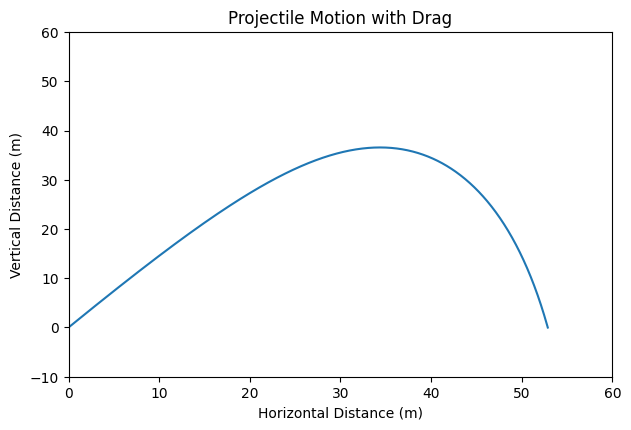

In [227]:
g = 9.81  # Acceleration due to gravity (m/s^2)
rho = 1.225  # Air density (kg/m^3)
Cd = 0.47  # Drag coefficient
A = 0.01  # Cross-sectional area (m^2)
m = 0.1  # Mass of the projectile (kg)
mu = 0.5 * rho * Cd * A

def runge_kutta_4th_order(f, x0, y0, h, n):
    x_vals = [x0]
    y_vals = [y0]
    while True:
        k1 = h * f(x_vals[-1], y_vals[-1])
        k2 = h * f(x_vals[-1] + h / 2, y_vals[-1] + k1 / 2)
        k3 = h * f(x_vals[-1] + h / 2, y_vals[-1] + k2 / 2)
        k4 = h * f(x_vals[-1] + h, y_vals[-1] + k3)

        x_vals.append(x_vals[-1] + h)
        y_vals.append(y_vals[-1] + (k1 + 2 * k2 + 2 * k3 + k4) / 6)
        if not y_vals[-1][2] > 0:
            break
        
    return torch.tensor(x_vals), torch.stack(y_vals)

def projectile_motion_with_drag(t, u):
    x, vx, y, vy = u


    v = torch.sqrt(vx**2 + vy**2)
    Fx = -mu * v * vx
    Fy = -mu * v * vy

    dxdt = vx
    dvxdt = (Fx / m)
    dydt = vy
    dvydt = (Fy / m) - g

    return torch.tensor([dxdt, dvxdt, dydt, dvydt], dtype=torch.float64)  # Use torch.tensor


# Initial conditions
x0 = 0.0
y0 = 0.0
vx0 = 40.0
vy0 = 60.0

u0 = torch.tensor([x0, vx0, y0,vy0], dtype=torch.float64)

# Time settings
t0 = 0.0
h = 0.01  # Step size
num_steps = 1000

# Solve the system of ODEs using Runge-Kutta 4th order
time_vals, x_y_components = runge_kutta_4th_order(projectile_motion_with_drag, t0, u0, h, num_steps)
#print(x_y_components)
# Extract position, velocity, and acceleration values
x_vals = x_y_components[:, 0]
vx_vals = x_y_components[:, 1]
y_vals = x_y_components[:, 2]
vy_vals = x_y_components[:, 3]

# Calculate acceleration components ax and ay
ax_vals = (-mu * vx_vals * np.sqrt(vx_vals**2 + vy_vals**2)) / m
ay_vals = (-mu * vy_vals * np.sqrt(vx_vals**2 + vy_vals**2)) / m - g

# Calculate velocity magnitude v
v_vals = torch.sqrt(vx_vals**2 + vy_vals**2)

# Calculate acceleration magnitude a
a_vals = torch.sqrt(ax_vals**2 + ay_vals**2)

# Plot the trajectory, velocity, and acceleration
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(x_vals, y_vals)
plt.title("Projectile Motion with Drag")
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Vertical Distance (m)")
plt.xlim(0, 60)
plt.ylim(-10, 60)
plt.grid(False)

plt.tight_layout()
plt.show()


# physics background

This PINN aims to simulate the trajectorie of a projectile slowed down by a drag force.

The the magnitude of the force is depedend on the following Parmeters:
1. rho the Air density (kg/m^3), 
2. Cd the drag coefficient, 
3. A the Cross-sectional area (m^2)

all these parameters can be summerized to one coefficiant:
- mu = 0.5 * rho * Cd * A

Furthermore is the drag force dependant on the square of the projectiles speed:
- F = mu * v * |v| 
where F can be split up in a x and a y component:
- Fx = mu * vx * |v| and 
- Fy = mu * vy * |v|

The resulting differential equations describe the path of the projectile:
- ax = Fx/m
- ay = Fy/m - g 

where m is the Mass of the projectile (kg) and g the earths gravitational acceleration

# Data import

In [238]:

def create_training_data(time_vals, x_y_components, num_t_train=10, sigma_noise=0, max_t_train=2):
    """
    Create training data for training procedure.

    This function generates training data using a subset
    of time values (time_vals Array) and corresponding state values (x_y_components Array).
    It can add optional noise to the state values. 
    Therefore the following steps need to be done:
    

    1. To select evenly spaced values from the `time_vals` and `x_y_components` arrays:
        - Create a list containing indices between 0 and 200 to select data points.
        - Ensure that the data type of this list is integer.

    2. To define `t_train`, `x_train`, and `y_train` tensors by selecting index values from `time_vals` and `x_y_components` using `torch.tensor(...)`:
        - Make sure the data type is float32.
        - Format the tensor size as `torch.Size([num_t_train, 1])`.

    3. To introduce possible noise to the data:
        - Generate a noise tensor with appropriate dimensions using the `torch.rand(...)` command.
        - Add the expression `sigma_noise * noise` to the `x_train` and `y_train` tensors.

    4. Return `t_train`, `x_train`, and `y_train`.
    
        
    Args:
    time_vals (torch.Tensor): A tensor containing time values.
    x_y_components (torch.Tensor): A tensor containing state values.
    num_t_train (int, optional): The number of data points to select from the
        provided time and state values. Default is 10.
    sigma_noise (float, optional): A scaling factor to add noise to the
        state values. Default is 0 (no noise).

    Returns:
    torch.Tensor: A tensor 't_train' containing selected time values for training.
    torch.Tensor: A tensor 'x_train' containing selected x-coordinate state values
        for training.
    torch.Tensor: A tensor 'y_train' containing selected y-coordinate state values
        for training.
    """
    
    # Step 1: Create a list of indices that correspond to the selected time values.
    idx = torch.linspace(0,max_t_train*100,num_t_train,dtype=torch.int)
    
    # Step 2: Get t_train, x_train and y_train by selecting values from the provided data.
    t_train = time_vals[idx].clone().detach().to(torch.float32).unsqueeze(1)
    x_train = x_y_components[idx,0].clone().detach().to(torch.float32).unsqueeze(1)
    y_train = x_y_components[idx,2].clone().detach().to(torch.float32).unsqueeze(1)
    
    # Step 3: Generate and noise times sigma_noise to x_train and y_train
    noise_x = torch.randn(num_t_train).unsqueeze(1)
    noise_y = torch.randn(num_t_train).unsqueeze(1)
    x_train += sigma_noise * noise_x
    y_train += sigma_noise * noise_y
    
    # Step 4: return t_train, x_train, y_train
    return t_train, x_train, y_train


# create PINN model

In [239]:
class PINN(nn.Module):
    """
    Physics-Informed Neural Network (PINN) Class
    
    This class as a subclass of nn.Module es the architecture of the PINN model, which is designed
    to use differential equations while incorporating physics-based constraints.
    The process consists of the following steps:
    
    1. Initialize the PINN model as a subclass of nn.Module.
    
    2. Build a Constructor to Configure the models's architecture. 
       Utilize the nn.Linear class from the PyTorch library for defining layers and connections.
       
    3. Define the forward pass mechanism for the model, where input data flows
       through the layers to produce predicted outputs.
       
    """
    def __init__(self):
        """
        Constructor for the PINN class.
        
        Initializes the layers of the neural network:
        - Input layer fc1 taking a tensor with time data.
        - One hidden fully connected layer fc2 with 64 neurons and GELU activation.
        - Output layer fc_x for predicting the x-coordinate.
        - Output layer fc_y for predicting the y-coordinate.
        
        Args:
            None
            
        Attributes:
            fc1 (nn.Linear): First fully connected layer.
            fc2 (nn.Linear): Second fully connected layer.
            fc_x (nn.Linear): Output layer for x-coordinate prediction.
            fc_y (nn.Linear): Output layer for y-coordinate prediction.
        
        Returns:
            None
        """
        super(PINN, self).__init__()
        
        # Step 2: Configure model architecture as described earlier
        self.fc1 = nn.Linear(1, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc_x = nn.Linear(64, 1)
        self.fc_y = nn.Linear(64, 1)
    
    def forward(self, x):
        """
        Perform a forward pass through the PINN model.
        
        This method defines the forward pass mechanism of the PINN model, where
        the input data x is processed through the layers to produce predicted
        outputs for both x-coordinate (x_output) and y-coordinate (y_output).
        The following steps are necessary:
        
        1. Retrieve the Data Type of fc1 Weights (dtype):
           - The dtype variable is assigned the data type of the weights associated with the fc1 linear layer.
           - This helps ensure consistent data types during computations.
        
        2. Apply the First Fully Connected Layer with GELU Activation:
           - Pass the input tensor x through the fc1 linear layer.
           - Convert the input to the dtype you have defined in step 1 data type for compatibility.
           - Apply the GELU activation function 'torch.nn.functional.gelu(...)' to the output.
        
        3. Apply the Second Fully Connected Layer with GELU Activation:
           - Pass the output of the previous step (x) through the fc2 linear layer.
           - Convert the input to the dtype as in the previous step.
           - Apply the GELU activation function to the output.
        
        4. Produce Predicted x and y Coordinates Using Output Layers:
           - Compute the predicted x-coordinate by passing the transformed tensor x through the fc_x layer.
           - Compute the predicted y-coordinate by passing the same transformed tensor x through the fc_y layer.
        
        Args:
            x (Tensor): Input data tensor.
            
        Returns:
            Tuple[Tensor, Tensor]: Predicted x and y coordinates.
        """
        # Step 1: Define dtype to retrieve the data type (dtype) of the weights associated with the fc1 
        #dtype = self.fc1.weight.dtype
        
        # Step 2: Apply the first fully connected layer with GELU activation
        x = torch.nn.functional.gelu(self.fc1(x))
        
        # Step 3: Apply the second fully connected layer with GELU activation
        x = torch.nn.functional.gelu(self.fc2(x))
        
        # Step 4: Produce predicted x and y coordinates using output layers
        x_output = self.fc_x(x)  # Predicted x-coordinate
        y_output = self.fc_y(x)  # Predicted y-coordinate
        
        return x_output, y_output


# Physicis informed loss

In [240]:
#physics_informed_loss.__doc__

In [241]:
def compute_physics_informed_loss(model, t_tensor):
    """
    Define the physics-informed loss for the PINN model.
    
    This function calculates the loss used to incorporate the underlying physics
    principles into the PINN. The following steps are involved:
    
    1. Enable gradient computation for the colocation points tensor, t_tensor.
    
    2. Predict x and y values by calling the neural network model.
    
    3. Compute the first gradients dx_dt and dy_dt, and second gradients d2x_dt2
       and d2y_dt2, using the torch.autograd.grad command

    4. Calculate the speed v using the Euclidean norm of the vector [dx_dt, dy_dt].
       Define the x and y component of the drag force as in the Data generation Block above.
       
    
    5. Define the differential equation residuals for both x and y components.
       (see [residuals](https://www.displayr.com/learn-what-are-residuals/))
       
    6. Calculate the mean squared residuals for both x and y using torch.mean().

    7. Return the combined physics-informed loss as the sum of loss_x and loss_y.
    
    Args:
        model (nn.Module): The physics-informed neural network model.
        t_tensor (torch.Tensor): train points tensor with requires_grad=True.
        
    Returns:
        torch.Tensor: The combined physics-informed loss.
    """
    # Step 1: Enable gradient computation for t_tensor
    t_tensor.requires_grad = True
    
    # Step 2: Predict x and y values using the neural network model
    x_pred, y_pred = model(t_tensor)
    
    # Step 3: Compute first and second gradients
    dx_dt = torch.autograd.grad(torch.sum(x_pred), t_tensor, create_graph=True)[0]
    d2x_dt2 = torch.autograd.grad(torch.sum(dx_dt), t_tensor, create_graph=True)[0]
    
    dy_dt = torch.autograd.grad(torch.sum(y_pred), t_tensor, create_graph=True)[0]
    d2y_dt2 = torch.autograd.grad(torch.sum(dy_dt), t_tensor, create_graph=True)[0]
    
    # Step 4: Calculate the speed v using the Euclidean norm and define x and y component of the drag force.
    v = torch.sqrt(dx_dt ** 2 + dy_dt ** 2)
    Fx = -mu * v * dx_dt
    Fy = -mu * v * dy_dt
    
    # Step 5: Define differential equation residuals
    residual_x = d2x_dt2 - Fx / m
    residual_y = d2y_dt2 - ((Fy / m) - g)
    
    # Step 6: Calculate mean squared residuals
    loss_x = torch.mean(residual_x ** 2)
    loss_y = torch.mean(residual_y ** 2)
    
    # Step 7: Return the combined physics-informed loss
    return loss_x + loss_y


# Data loss

In [242]:
def compute_data_loss(model, t_train,x_train, y_train):
    """
    Define the data loss for the PINN model.
    
    This function calculates the loss based on the discrepancy between the predicted
    and actual data points, typically used for data-driven training of the PINN. The
    following steps are involved:
    
    1. Compute the predicted x and y values by calling the neural network model.
    
    2. Calculate the mean squared error loss for both the x and y components using the nn.MSELoss() class.
       (see [MSELoss](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html))
       
    3. Return the combined data loss as the sum of mse_x and mse_y.
    
    Args:
        model (nn.Module): The physics-informed neural network model.
        t_sol_rnd (torch.Tensor): Randomly selected solution points tensor.
        
    Returns:
        torch.Tensor: The combined data loss based on predicted vs. actual data.
    """
    # Step 1: Compute predicted x and y values using the neural network model
    x_pred, y_pred = model(t_train)
    
    # Step 2: Calculate mean squared error loss
    mse_loss = nn.MSELoss()
    mse_x = mse_loss(x_pred, x_train)
    mse_y = mse_loss(y_pred, y_train)
    
    # Step 3: Return the combined data loss
    return mse_x + mse_y

# Total Loss

In [243]:
def compute_total_loss(model, t_train, x_train, y_train, t_col):
    """
    Define the total loss for the physics-informed neural network.
    
    This function computes the total loss for the PINN model by combining three
    different components: data loss, and physics-informed loss.
    The following steps are involved:
    
    1. Compute the physics-informed loss by calling the compute_physics_informed_loss() function.
    
    3. Determine the data loss using the compute_data_loss() function.
    
    4. Return the combined total loss as the sum of data_loss and phys_loss.
    
    Args:
        model (nn.Module): The physics-informed neural network model.
        
    Returns:
        torch.Tensor: The combined total loss considering data, boundary, and physics constraints.
    """
        
        # Step 1: Compute physics-informed loss
    phys_loss = compute_physics_informed_loss(model, t_col)
    
    # Step 3: Determine data loss
    data_loss = compute_data_loss(model, t_train, x_train, y_train)
    
    # Step 4: Return combined total loss
    return data_loss +  phys_loss


# Executive function

In [285]:
# Initialize the model by calling the PINN() class created earlier.
model = PINN()

def execute(lr=0.01, 
            num_epochs=1000, 
            num_t_train=10,
            max_t_train=2,
            sigma_noise=0, 
            weight_decay=1e-5,
            num_t_col=None,
            start=0,
            max_t_col=5,):  # Adjust weight_decay for L2 regularization
    """
    Execute the training procedure for a physics-informed neural network model.

    This function trains the model using specified hyperparameters and returns relevant data.
    The process involves the following steps:
    
    Step 1:. The optimizer is used to update the model's parameters during training. Therefore:
        - Initialize the optimizer, Adam with the model parameters.
        - Configure it with a specified learning rate (lr) and weight decay (weight_decay).
        
    Step 2: Define 't_train,' 'x_train,' and 'y_train' by calling ‘create_training_data(…)' and configure it with  'time_vals,' 'x_y_components,' 'num_t_train,' and 'sigma_noise.'  

    Step 3: In order to store the values of the loss function during the training process:
            - Initialize a list called 'loss_evolution'. 

    Step 4: Set up a training loop that will run for a specified number of epochs ('num_epochs'). An epoch is one complete pass through the entire training dataset.

    Step 5: - Inside the training loop, the optimizer's gradient is reset to zero using 'optimizer.zero_grad()' to prepare for a new gradient calculation. 
            - Then, the model 'model' is used to make predictions ('x_pred' and 'y_pred') based on the 't_train' data.

    Step 6: - Calculate the total loss by calling the 'compute_total_loss' function. 
            - Additionally, include a term for L2 regularization, by using the torch.norm() with p=2 command. 
            - Then sum over all parameters in model.parameters().

    Step 7: Then calculate the gradients of the model's parameters with respect to the total loss using 'loss.backward()'. 
            These gradients will be used by the optimizer to update the model's parameters.

    Step 8: - Now append the current loss value (including regularization) to the 'loss_evolution' list for later analysis. 
            - Additionally, every 100 epochs, the code prints the current epoch number and the value of the loss.

    Step 9: Once the training loop is completed (all epochs are max_t_coled), return: 't_train,' 'x_train,' 'y_train,' 'loss_evolution' and 'num_epochs'.


    Args:
        lr (float, optional): Learning rate for the optimizer. Default is 0.01.
        num_epochs (int, optional): Number of training epochs. Default is 1000.
        num_t_train (int, optional): The number of data points to select from the
            provided time and state values. Default is 10.
        sigma_noise (float, optional): A scaling factor to add noise to the
            state values. Default is 0 (no noise).
        weight_decay (float, optional): Weight decay (L2 regularization) strength for the optimizer.
            Default is 1e-5.

    Returns:
        torch.Tensor: A tensor 't_train' containing selected time values for training.
        torch.Tensor: A tensor 'x_train' containing selected x-coordinate state values for training.
        torch.Tensor: A tensor 'y_train' containing selected y-coordinate state values for training.
        list: A list containing loss values during training.
        int: The number of training epochs.
    
    """    
    
    # Step 1: Initialize optimizer 
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)  # Include weight_decay in the optimizer
    
    # Step 2: Create traning data
    t_train, x_train, y_train = create_training_data(time_vals, 
                                                     x_y_components, 
                                                     num_t_train=num_t_train, 
                                                     sigma_noise=sigma_noise,
                                                     max_t_train=max_t_train)
    if num_t_col == None:
        t_col = t_train
    else:
        t_col = torch.linspace(start,max_t_col,num_t_col).unsqueeze(1)
        
    # Step 3: Initialize the loss evolution list.
    loss_evolution = []

    # Step 4: Set up the training loop
    for epoch in range(num_epochs):
        
        # Step 5: Reset the optimizers gradient and call the model prediction
        optimizer.zero_grad()
        x_pred, y_pred = model(t_train)
        
        # Step 6: Compute the total loss.
        loss = compute_total_loss(model, t_train, x_train, y_train, t_col)
    
        # Calculate the L2 regularization term and add to the loss.
        l2_regularization = 0.0
        for param in model.parameters():
            l2_regularization += torch.norm(param, p=2)  # L2 norm of parameters
            
        loss += weight_decay * l2_regularization
        
        # Step 7 calculate the gradients using backpropagation
        loss.backward()
        optimizer.step()
        
        # Step 8: Store the current loss value in the loss history and print every 100th epoch the Loss.
        loss_evolution.append(float(loss))
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item()}')
            
    # Step 9: return t_train, x_train, y_train, loss_evolution, num_epochs
    return t_train, x_train, y_train, loss_evolution, num_epochs
t_train, x_train, y_train, loss_evolution, num_epochs = execute(num_epochs = 200, 
                                                                num_t_train=30,
                                                                max_t_train=2,
                                                                lr=0.01, 
                                                                sigma_noise=0, 
                                                                num_t_col=10,
                                                                max_t_col=time_vals[-1])

Epoch [10/200], Loss: 627.9799194335938
Epoch [20/200], Loss: 221.31658935546875
Epoch [30/200], Loss: 121.65109252929688
Epoch [40/200], Loss: 71.69031524658203
Epoch [50/200], Loss: 52.10144805908203
Epoch [60/200], Loss: 37.11949920654297
Epoch [70/200], Loss: 16.921875
Epoch [80/200], Loss: 2.7211315631866455
Epoch [90/200], Loss: 0.7741883397102356
Epoch [100/200], Loss: 0.5852722525596619
Epoch [110/200], Loss: 0.23466481268405914
Epoch [120/200], Loss: 0.17355430126190186
Epoch [130/200], Loss: 0.1158532053232193
Epoch [140/200], Loss: 0.08559586107730865
Epoch [150/200], Loss: 0.08543632924556732
Epoch [160/200], Loss: 0.16454772651195526
Epoch [170/200], Loss: 0.10412062704563141
Epoch [180/200], Loss: 0.09452521055936813
Epoch [190/200], Loss: 0.05998744070529938
Epoch [200/200], Loss: 0.054841116070747375


# Network prediction


In [286]:
# Generate 1000 random evaluation points between 0 and 10
t_eval = torch.linspace(0, 5.41, 200).reshape(-1, 1)

# Evaluate the trained model
x_pred, y_pred = model(t_eval)

# Plot

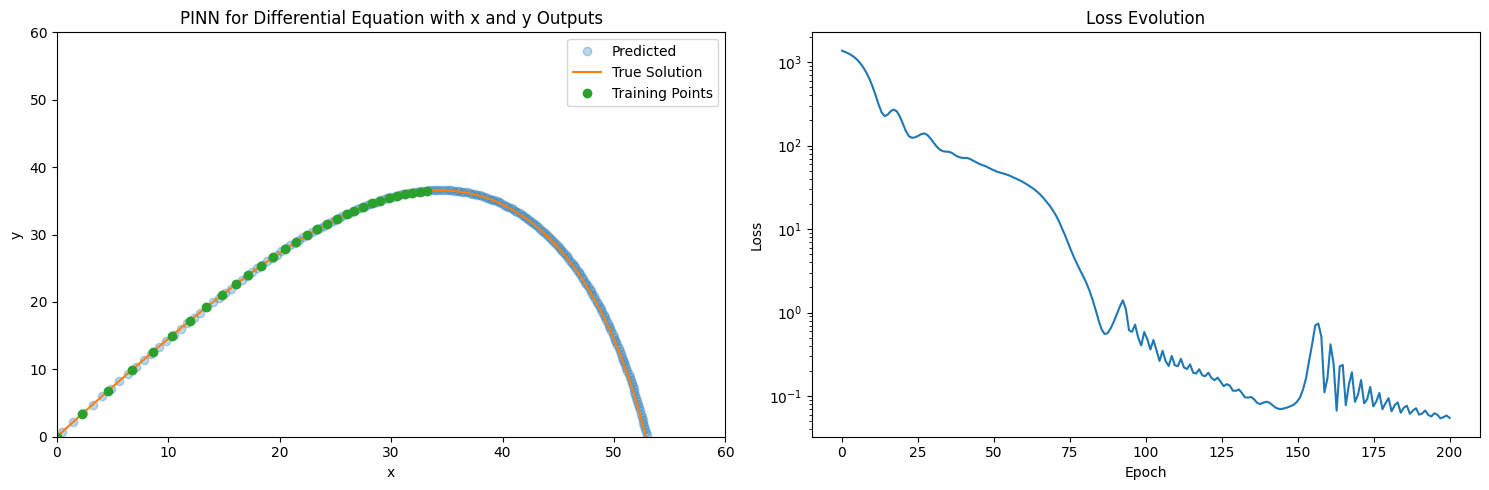

In [287]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure with subplots
fig, axs = plt.subplots(1, 2, figsize=(15,5))  # 1 row, 2 columns of subplots

# Plot data on the first subplot
axs[0].plot(x_pred.detach().numpy(), y_pred.detach().numpy(), 'o', alpha=0.3, label='Predicted')
axs[0].plot(x_y_components[:,0], x_y_components[:,2], label='True Solution')
axs[0].plot(x_train.detach().numpy(), y_train.detach().numpy(), 'o', label='Training Points')
axs[0].legend()
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
axs[0].set_title('PINN for Differential Equation with x and y Outputs')
axs[0].set_ylim(0, 60)
axs[0].set_xlim(0, 60)

# Plot loss evolution on the second subplot

axs[1].plot(np.linspace(0, num_epochs, len(loss_evolution)), loss_evolution)
axs[1].set_title('Loss Evolution')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].set_yscale('log')  # Set y-axis to logarithmic scale
# Adjust layout for subplots
plt.tight_layout()

# Show the plot
plt.show()


In [288]:
i = 0
j=0
v = torch.zeros(6).unsqueeze(1)
#w = 
for i in range(3):
    for j in range(5):
        j=j+1
        v[j] = j
    i = i+1
    
    v[i] = i
print(i)
print(v.shape)

3
torch.Size([6, 1])
